=>---------Target Column:

| Column | Meaning         |
| ------ | --------------- |
| Class  | Target Variable |


=>--------Class Values

0 = Normal Transaction
1 = Fraud Transaction

# Step 1: Import Required Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')

# Step 2: Load Dataset

In [2]:
df = pd.read_csv("GB_Creditcard.csv")

print(df.shape)
df.head(5)

(35791, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


# Step 3: Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35791 entries, 0 to 35790
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    35791 non-null  int64  
 1   V1      35791 non-null  float64
 2   V2      35791 non-null  float64
 3   V3      35791 non-null  float64
 4   V4      35791 non-null  float64
 5   V5      35791 non-null  float64
 6   V6      35791 non-null  float64
 7   V7      35791 non-null  float64
 8   V8      35791 non-null  float64
 9   V9      35791 non-null  float64
 10  V10     35791 non-null  float64
 11  V11     35791 non-null  float64
 12  V12     35791 non-null  float64
 13  V13     35791 non-null  float64
 14  V14     35791 non-null  float64
 15  V15     35791 non-null  float64
 16  V16     35791 non-null  float64
 17  V17     35791 non-null  float64
 18  V18     35791 non-null  float64
 19  V19     35791 non-null  float64
 20  V20     35791 non-null  float64
 21  V21     35791 non-null  float64
 22

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,...,35791.000000,35790.000000,35790.000000,35790.000000,35790.000000,35790.000000,35790.000000,35790.000000,35790.000000,35790.000000
mean,24016.817468,-0.207898,0.072287,0.718419,0.195676,-0.216779,0.095746,-0.116891,0.032751,0.258905,...,-0.030882,-0.113601,-0.041585,0.007352,0.135954,0.021732,0.010634,0.003836,84.191441,0.002878
std,12426.331378,1.836236,1.539877,1.540295,1.408997,1.388189,1.310393,1.257092,1.241560,1.237865,...,0.769358,0.640285,0.544919,0.593326,0.435953,0.506560,0.389455,0.301933,227.174740,0.053570
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-42.147898,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.438650,-8.567638,-9.617915,0.000000,0.000000
25%,12315.000000,-0.959617,-0.499846,0.244746,-0.714642,-0.818345,-0.644924,-0.598035,-0.155541,-0.523536,...,-0.239559,-0.536457,-0.178395,-0.327339,-0.127247,-0.331774,-0.063199,-0.007234,6.990000,0.000000
50%,29015.000000,-0.233059,0.113371,0.827531,0.188855,-0.255435,-0.162857,-0.073069,0.043456,0.134731,...,-0.081580,-0.087588,-0.051990,0.061739,0.175757,-0.063468,0.008863,0.021090,22.000000,0.000000
75%,34275.500000,1.162290,0.754515,1.456338,1.078772,0.302947,0.485272,0.436313,0.307472,0.991308,...,0.094936,0.296443,0.076204,0.398765,0.421069,0.301112,0.086736,0.075987,76.000000,0.000000
max,38267.000000,1.960497,16.713389,4.101716,13.143668,34.099309,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,13.876221,4.014444,5.525093,3.517346,11.135740,5.678671,7879.420000,1.000000


# Step 4: Check Missing Values

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

In [6]:
# Drop rows with missing values
df.dropna(inplace=True)

print("Shape after dropping NaN:", df.shape)

Shape after dropping NaN: (35790, 31)


# Step 5: Fraud vs Normal Distribution

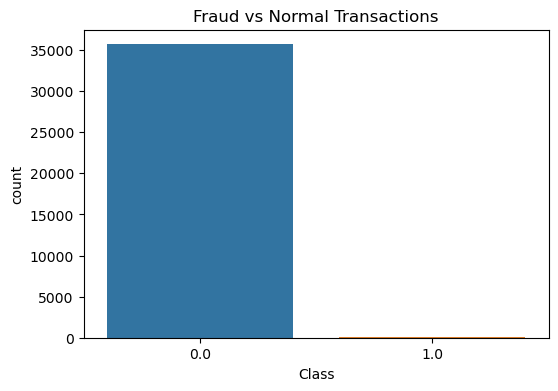

In [7]:
plt.figure(figsize = (6,4))

sns.countplot(x = 'Class', data = df)

plt.title("Fraud vs Normal Transactions")

plt.show()

# Step 6: Fraud Percentage

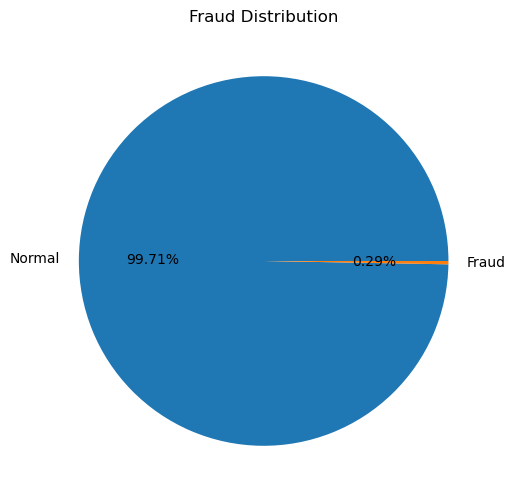

In [8]:
fraud = df['Class'].value_counts()

plt.figure(figsize = (6,6))

plt.pie(
    fraud, 
    labels = ['Normal', 'Fraud'],
    autopct = '%1.2f%%'
)

plt.title("Fraud Distribution")

plt.show()

# Step 7: Amount Distribution

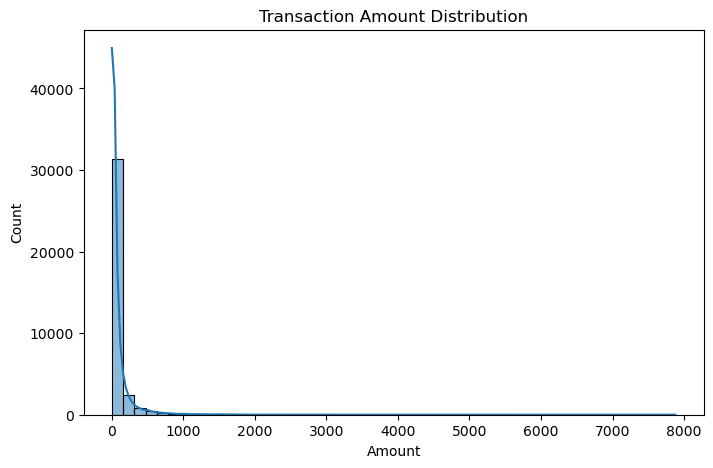

In [9]:
plt.figure(figsize = (8,5))

sns.histplot(
    df['Amount'],
    bins = 50,
    kde = True
)

plt.title("Transaction Amount Distribution")
plt.show()

# Step 8: Time Distribution

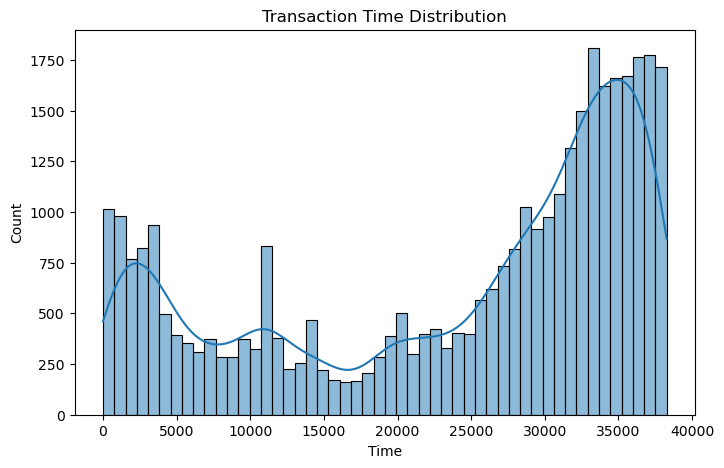

In [10]:
plt.figure(figsize = (8,5))

sns.histplot(
    df['Time'],
    bins = 50,
    kde = True
)

plt.title("Transaction Time Distribution")
plt.show()

# Step 9: Correlation Heatmap

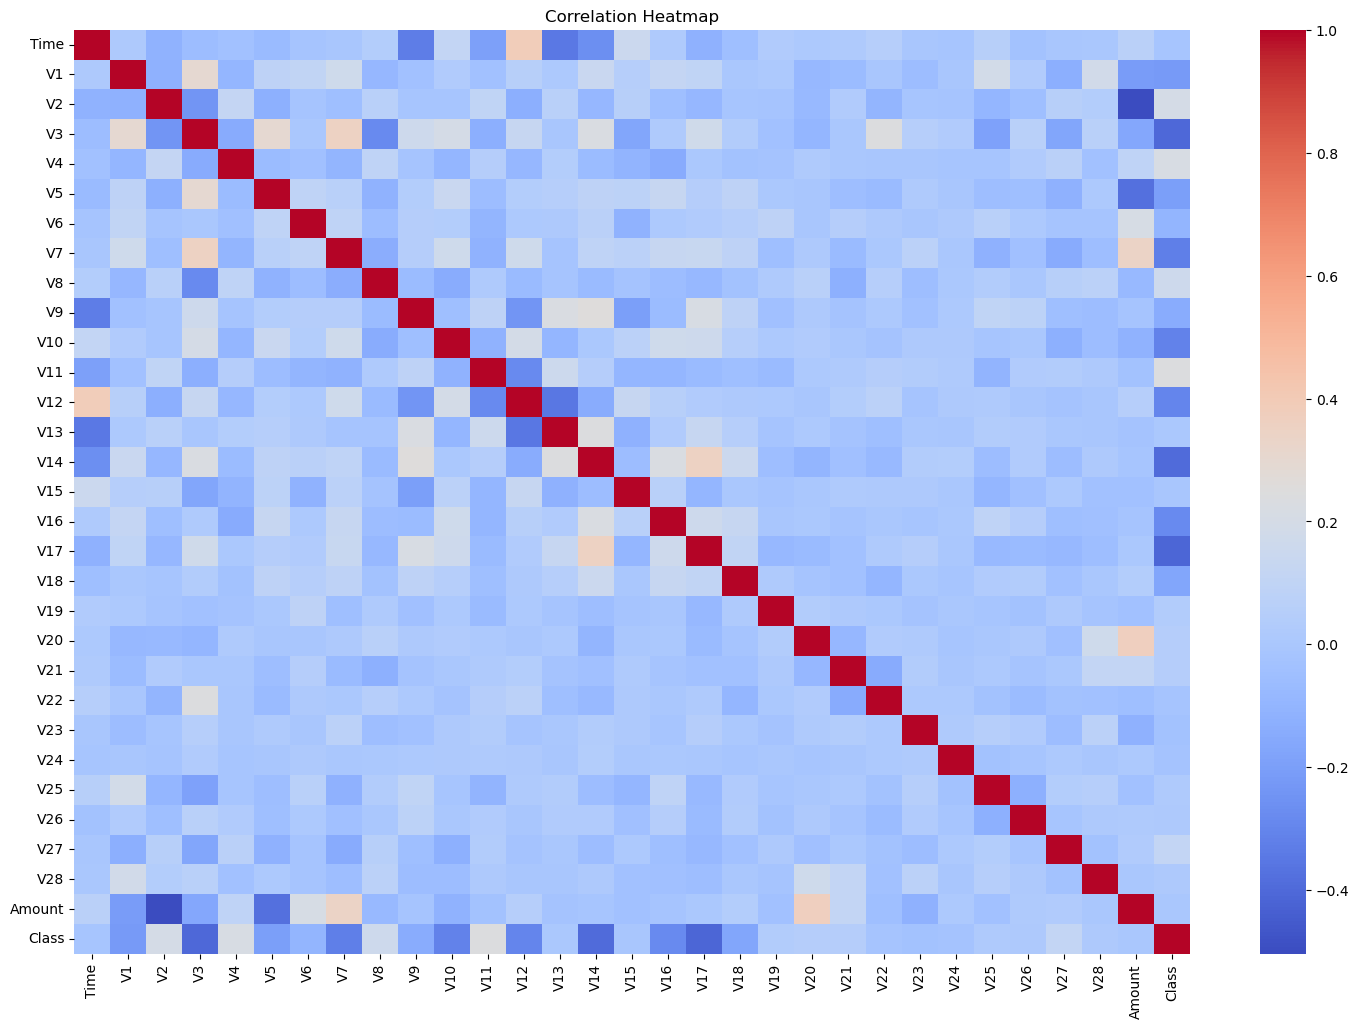

In [11]:
plt.figure(figsize = (18,12))

sns.heatmap(
    df.corr(),
    cmap = 'coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# Step 10: Separate Features and Target

In [12]:
X = df.drop("Class", axis = 1)

y = df["Class"]

# Step 11: Feature Scaling

In [13]:
scaler = StandardScaler()

X['Time'] = scaler.fit_transform(X[['Time']])

X['Amount'] = scaler.fit_transform(X[['Amount']])

# Step 12: Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
)

print(X_train.shape)
print(X_test.shape)

(28632, 30)
(7158, 30)


# Step 13: Build Gradient Boosting Model

In [15]:
gb_model = GradientBoostingClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 4,
    random_state = 42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=200,
                           random_state=42)

# Step 14: Make Predictions

In [16]:
y_pred = gb_model.predict(X_test)

y_prob = gb_model.predict_proba(X_test)[:, 1]

# Step 15: Model Evaluation

In [17]:
print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("ROC AUC   :", roc_auc_score(y_test, y_prob))

Accuracy  : 0.9988823693769209
Precision : 1.0
Recall    : 0.6363636363636364
F1 Score  : 0.7777777777777778
ROC AUC   : 0.852992509172442


# Step 16: Classification Report

In [18]:
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7136
       Fraud       1.00      0.64      0.78        22

    accuracy                           1.00      7158
   macro avg       1.00      0.82      0.89      7158
weighted avg       1.00      1.00      1.00      7158



# Step 17: Confusion Matrix

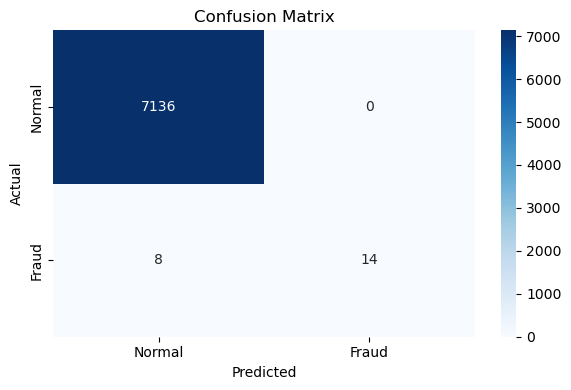

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Step 18: ROC Curve

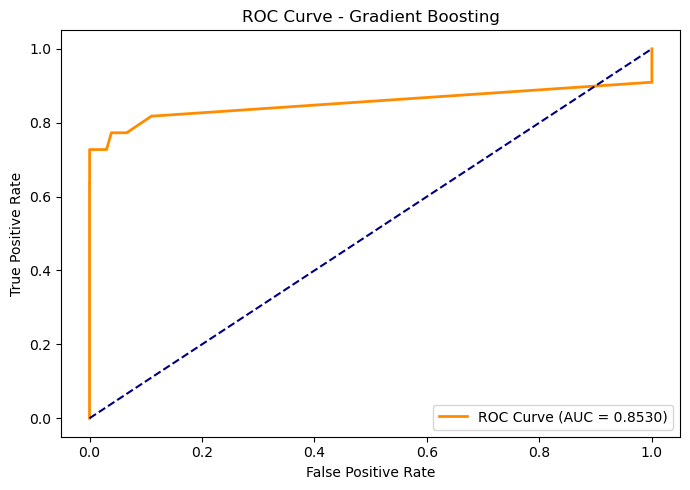

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Step 19: AUC Score

In [25]:
print("AUC Score :", round(auc_score,4))

AUC Score : 0.853


# Step 20: Feature Importance

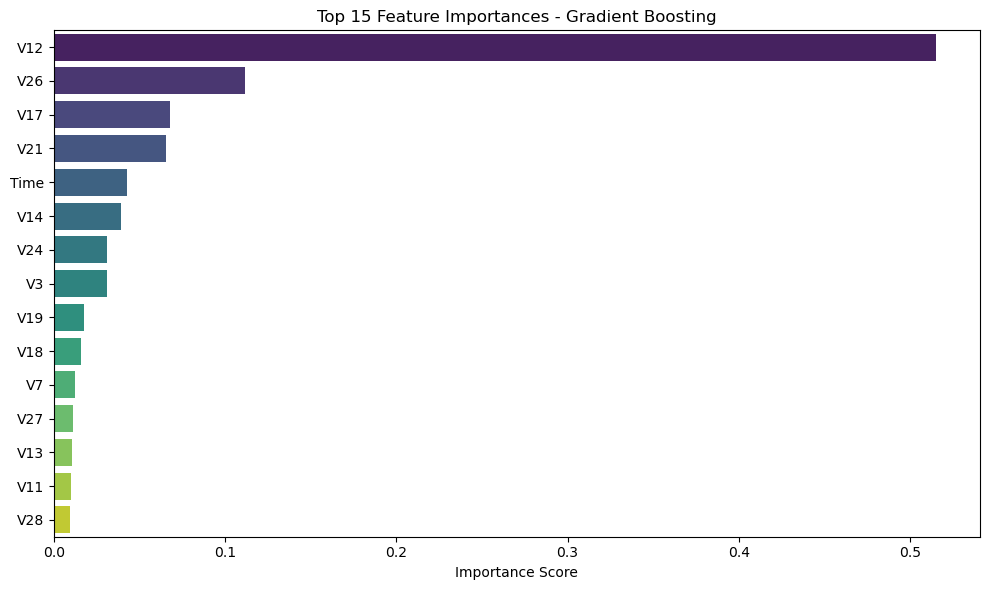

In [26]:
feature_importances = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values[:15],
            y=feature_importances.index[:15],
            palette='viridis')
plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Step 21: Training Accuracy

In [27]:
train_pred = gb_model.predict(X_train)

train_acc = accuracy_score(
    y_train,
    train_pred
)

print("Training Accuracy :", train_acc)

Training Accuracy : 1.0


# Step 22: Testing Accuracy

In [28]:
test_acc = accuracy_score(y_test, y_pred)

print("Testing Accuracy :", test_acc)

Testing Accuracy : 0.9988823693769209


# Step 23: Overfitting Check

In [30]:
difference = train_acc - test_acc

print("Training Accuracy :", round(train_acc*100,2))
print("Testing Aaccuracy :", round(test_acc*100,2))

print("Difference :", round(difference*100,2))

Training Accuracy : 100.0
Testing Aaccuracy : 99.89
Difference : 0.11


# Step 24: Actual vs Predicted

In [32]:
results = pd.DataFrame({
    'Actual' : y_test,
    'Predicted': y_pred
})

results.head(20)

,Actual,Predicted
10941,0.0,0.0
12710,0.0,0.0
13705,0.0,0.0
35360,0.0,0.0
22699,0.0,0.0
9632,0.0,0.0
13912,0.0,0.0
7534,0.0,0.0
31974,0.0,0.0
6427,1.0,1.0


# Step 25: Fraud Detection Probability

In [33]:
prob_df = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_prob
})

prob_df.head(20)

,Actual,Predicted
10941,0.0,2.301681e-07
12710,0.0,2.301681e-07
13705,0.0,2.301681e-07
35360,0.0,2.301681e-07
22699,0.0,2.301681e-07
9632,0.0,2.301681e-07
13912,0.0,2.301681e-07
7534,0.0,2.301681e-07
31974,0.0,2.614817e-07
6427,1.0,9.999892e-01


# Step 26: Save Model

In [34]:
import joblib

joblib.dump(
    gb_model,
    "Gradient_Boosting_CrediCard.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


| Metric    | Expected Range |
| --------- | -------------- |
| Accuracy  | 99%+           |
| Precision | 85%+           |
| Recall    | 80%+           |
| F1 Score  | 82%+           |
| ROC-AUC   | 95%+           |
